# Task 1.2 - Modeling and Tuning (capacity CNN, notebook-first)

Canonical Task 1.2 modeling notebook. Supersedes `old_02_task12_modeling_and_tuning.ipynb`
(the plain 5-conv k=16 line, runs 1-23). Clean protocol only; `validation_augmented` is
reported for context (Task 1.3 handles robustness separately). Develops here, then ports to
`solution/` only if/when we commit to submitting it (`_lib` is untouched so the live
pipeline cannot clash). Consumes the `solution/artifacts/prepared/` caches (from
`prepare.py`) and `notebook_cache/budget.json`.

## Why this architecture (the run-23 -> run-24 redesign)

The old model (`build_cnn_bn`, k=16, ~250k params) plateaued and early-stopped well before
the budget; neither more time (script runs) nor more width (k=32) helped. Diagnosis: it is
parameter-poor but FLOPs-heavy in the wrong place. It stops downsampling after two pools, so
its last three convs run at 40x40 and 56% of its 424M MACs/img sit in one 128->128 conv -
budget spent on resolution it cannot exploit instead of on capacity.

Deeper reason it mattered: recall_ai at fpr<=0.20 is an operating point bounded by the ROC,
i.e. by AUC. Across runs 7-23 every loss/resolution/width/threshold tweak only slid the
operating point along essentially the same curve (ensemble holdout AUC stuck at 0.877-0.915);
PASS/FAIL flips were seed and threshold variance, not real gains. The only lever left was a
genuinely more powerful model that raises the ROC.

Redesign (ResNet-style): downsample to stride-4 immediately (stem conv s2 + maxpool), then 4
residual stages widening 32/64/128/256 with squeeze-excitation. This buys ~11x the parameters
(2.84M) at ~0.75x the MACs (319M/img at 192px) - more capacity at less compute - so it keeps
learning through the whole budget and affords 192px input. Now residual blocks serve their
real purpose (17-conv-deep net), plus a warmup+cosine LR schedule the old runs lacked. See
`task12_experiment_log.md` "Post-Run-23" for the full reasoning, including why the earlier
run-16 ResBlock attempt did not help.

## Run-23 baseline this beats (hardcoded in the comparison cell)

| model | split | recall | fpr | auc |
|---|---|---|---|---|
| CNN | holdout | - | - | 0.879 |
| ENS | val | 0.811 | 0.170 | 0.888 |
| ENS | val_aug | 0.604 | 0.289 | 0.734 |

Exit criteria: CNN-alone holdout AUC > 0.879, and ensemble val recall >= 0.80 at fpr <= 0.20.
Achieved (run 24): CNN holdout AUC 0.915; ENS val 0.849 @ 0.186, AUC 0.903.

## C.0 - Setup, budget, knobs

Budget = 5x the cached Appendix-C reference (`budget.json`), identical value and
protocol to Task 1.2 / notebook 05. We do NOT re-time the reference here (decision:
reuse the documented number; the grader runs the dummy-train reference on its own
hardware and we must stay under 5x). Caches are reused read-only; this notebook
never rebuilds them.

In [27]:
import os, sys, time, json
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score, accuracy_score, roc_auc_score,
    confusion_matrix,
)

ROOT = Path.cwd().parent
SOLUTION = ROOT / "solution"
sys.path.insert(0, str(SOLUTION))

from _lib import seed
from _lib.model import FocalLoss, class_weights, batch_to_chw, cnn_scores, build_cnn_bn
from _lib.calibration import pick_threshold_for_fpr

seed.set_deterministic(0)  # once per kernel; also caps threads to 8 (matches grader --cpus 8)

PREP    = SOLUTION / "artifacts" / "prepared"
NBCACHE = SOLUTION / "artifacts" / "notebook_cache"
IMG_SIZE = 224  # cache resolution, do not change
CLASS_NAMES = {0: "real", 1: "SD2.1", 2: "SDXL", 3: "SD3", 4: "DALL-E3", 5: "Midjourney"}

# --- knobs --------------------------------------------------------------------
TRAIN_IMG_SIZE = 192    # CNN forward/backward resolution (benchmark cell may lower it)
# Architecture variant (idea 3): BasicBlocks per stage. Baseline (runs 24-26) = (2,2,2,2).
# This run = (2,2,2,3): a 3rd block in stage 4 (deepest, runs at 6x6 @192px), the cheapest
# capacity bump (extra params, ~+13% MACs) to test whether the plateaued ROC (holdout AUC ~0.916
# CNN / ~0.928 ENS across runs 24-26) has any headroom left from more capacity. Set back to
# (2,2,2,2) to reproduce run 26.
CNN_BLOCKS     = (2, 2, 2, 3)
PEAK_LR        = 1e-3   # cosine peak; drop to 5e-4 if early loss diverges
LR_FLOOR_FRAC  = 0.01   # cosine floor = LR_FLOOR_FRAC * PEAK_LR
WARMUP_CAP     = 300    # max warmup steps
BATCH          = 64
PATIENCE       = 12     # guard only; we WANT it to train through to the deadline
TARGET_FPR_CAL = 0.18   # ~0.02 headroom under the 0.20 limit (run 25: 0.19 left none, val fpr crept to 0.207)
CHANNELS_LAST  = True   # oneDNN NHWC convs; benchmark cell confirms it helps
# Step-based, tail-weighted eval (idea 2). The checkpoint is selected by HOLDOUT AUC, not
# recall@fpr, and the model improves to the last step under cosine-to-0, so evals must be
# reproducible (step-based, not wall-clock) and dense at the end. N_EVALS_TARGET scheduled evals
# with gaps that shrink toward the deadline (EVAL_TAIL_POWER>1), plus one guaranteed final eval of
# the last weights. Total eval cost stays ~N_EVALS_TARGET passes (bounded), matching run 25.
N_EVALS_TARGET = 16
EVAL_TAIL_POWER = 2.0
# idea-1 run: trim the CNN-budget reserve. It must still cover the in-budget post-CNN work the
# grader runs (guaranteed final holdout eval + RF refit + calibration + model save) PLUS safety
# for a slower grader, since the whole pipeline has to fit in 5x reference. Run 24 used 70s
# (over-conservative); post-CNN work is ~18s (final eval ~8s + RF ~10s). 45s reclaims time for
# the CNN and still leaves ~27s margin -> ~4.8x total. The C.7c assert proves it covered the work.
CNN_BUDGET_RESERVE_S = 45.0
# -----------------------------------------------------------------------------

REF_S = json.loads((NBCACHE / "budget.json").read_text())["reference_elapsed_s"]
BUDGET_S = 5.0 * REF_S
print(f"reference={REF_S:.1f}s  ->  5x budget={BUDGET_S:.0f}s")
print(f"train_img_size={TRAIN_IMG_SIZE}  blocks={CNN_BLOCKS}  peak_lr={PEAK_LR}  batch={BATCH}  channels_last={CHANNELS_LAST}")
assert PREP.exists() and (PREP / "X_fit.mmap").exists(), "run solution/prepare.py first"

reference=155.6s  ->  5x budget=778s
train_img_size=192  blocks=(2, 2, 2, 3)  peak_lr=0.001  batch=64  channels_last=True


## C.1 - Load prepared splits + metrics helpers

Same `artifacts/prepared/` caches `train.py` consumes: uint8 (N,224,224,3) memmaps
plus binary labels `y`, source class `src` (0..5), and 101-dim engineered features
`F` for the RF. `metrics_block` / `print_metrics` copied verbatim from notebook 02.

In [28]:
def load_split(name):
    n   = int(np.load(PREP / f"n_{name}.npy")[0])
    X   = np.lib.format.open_memmap(str(PREP / f"X_{name}.mmap"), mode="r",
                                    dtype=np.uint8, shape=(n, IMG_SIZE, IMG_SIZE, 3))
    y   = np.load(PREP / f"y_{name}.npy")
    src = np.load(PREP / f"src_{name}.npy")
    Ff  = np.load(PREP / f"F_{name}.npy")
    return X, y, src, Ff

X_fit,  y_fit,  src_fit,  F_fit  = load_split("fit")
X_hold, y_hold, src_hold, F_hold = load_split("hold")
X_cal,  y_cal,  src_cal,  F_cal  = load_split("cal")
X_val,  y_val,  src_val,  F_val  = load_split("val")
X_va,   y_va,   src_va,   F_va   = load_split("va")
MEAN = np.load(PREP / "mean.npy")
STD  = np.load(PREP / "std.npy")
print(f"fit={len(X_fit)}  hold={len(X_hold)}  cal={len(X_cal)}  val={len(X_val)}  va={len(X_va)}")
print(f"fit class balance: real={int((y_fit==0).sum())}  ai={int((y_fit==1).sum())}")


def metrics_block(y_true, scores, src, threshold, target_fpr=None):
    y_true = np.asarray(y_true); scores = np.asarray(scores); src = np.asarray(src)
    y_pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = int(cm[0,0]), int(cm[0,1]), int(cm[1,0]), int(cm[1,1])
    out = {
        "threshold":    float(threshold),
        "target_fpr":   float(target_fpr) if target_fpr is not None else None,
        "recall_ai":    float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "fpr_real":     float(fp / (fp + tn)) if (fp + tn) else 0.0,
        "precision_ai": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "accuracy":     float(accuracy_score(y_true, y_pred)),
        "f1_ai":        float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "roc_auc":      float(roc_auc_score(y_true, scores)) if len(np.unique(y_true)) > 1 else float("nan"),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp, "n": int(len(y_true)),
    }
    per = {}
    for c in range(1, 6):
        mask = src == c
        per[c] = float((y_pred[mask] == 1).mean()) if mask.sum() else float("nan")
    out["per_source_class_recall"] = per
    return out


def print_metrics(tag, m):
    print(f"[{tag}]  recall_ai={m['recall_ai']:.3f}  fpr_real={m['fpr_real']:.3f}  "
          f"prec_ai={m['precision_ai']:.3f}  acc={m['accuracy']:.3f}  f1={m['f1_ai']:.3f}  "
          f"auc={m['roc_auc']:.3f}  thr={m['threshold']:.3f}  n={m['n']}")
    pcr = m["per_source_class_recall"]
    parts = "  ".join(f"{CLASS_NAMES[c]}:{pcr[c]:.2f}" for c in range(1, 6))
    print(f"    confusion: tn={m['tn']} fp={m['fp']} fn={m['fn']} tp={m['tp']}   per-class AI: {parts}")

fit=26718  hold=2970  cal=1924  val=1124  va=1124
fit class balance: real=4453  ai=22265


## C.2 - Architecture

Stem conv3x3 s2 + MaxPool2 (stride-4) -> 4 residual stages (`CNN_BLOCKS` BasicBlocks
each; baseline (2,2,2,2), this run (2,2,2,3)), widths 32/64/128/256, stride-2 entry on
stages 2-4, with squeeze-excitation -> GAP -> Dropout -> Linear. Standard 3x3 convs
(not depthwise-separable): AI-artifact detection needs joint spatial+channel mixing, and
run 17 showed DW-sep hurt.

In [29]:
class SEBlock(nn.Module):
    """Squeeze-excitation channel attention. Cheap on CPU, recalibrates channels."""
    def __init__(self, ch, reduction=8):
        super().__init__()
        hidden = max(ch // reduction, 4)
        self.fc1 = nn.Linear(ch, hidden)
        self.fc2 = nn.Linear(hidden, ch)

    def forward(self, x):
        s = x.mean(dim=(2, 3))                 # GAP -> (N, C)
        s = torch.sigmoid(self.fc2(F.relu(self.fc1(s))))
        return x * s.unsqueeze(-1).unsqueeze(-1)


class BasicBlock(nn.Module):
    """ResNet basic block: 2x conv3x3-BN with SE on the residual branch, then skip."""
    def __init__(self, in_c, out_c, stride=1, se_reduction=8):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_c)
        self.se    = SEBlock(out_c, se_reduction)
        self.down  = None
        if stride != 1 or in_c != out_c:
            self.down = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c),
            )

    def forward(self, x):
        idt = x if self.down is None else self.down(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.se(self.bn2(self.conv2(out)))
        return F.relu(out + idt, inplace=True)


class CapacityCNN(nn.Module):
    def __init__(self, widths=(32, 64, 128, 256), blocks=(2, 2, 2, 2),
                 se_reduction=8, dropout=0.2, num_classes=2):
        super().__init__()
        c0 = widths[0]
        self.stem = nn.Sequential(
            nn.Conv2d(3, c0, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(c0), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        stages, in_c = [], c0
        for si, (w, nb) in enumerate(zip(widths, blocks)):
            for bi in range(nb):
                stride = 2 if (bi == 0 and si > 0) else 1
                stages.append(BasicBlock(in_c, w, stride=stride, se_reduction=se_reduction))
                in_c = w
        self.stages = nn.Sequential(*stages)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(in_c, num_classes),
        )

    def forward(self, x):
        return self.head(self.stages(self.stem(x)))


def build_capacity_cnn(**kw):
    kw.setdefault("blocks", CNN_BLOCKS)   # idea-3 knob; defaults to the C.0 setting
    return CapacityCNN(**kw)


def count_macs(model, img_size):
    total = [0]
    def hook(m, inp, out):
        if isinstance(m, nn.Conv2d):
            oh, ow = out.shape[2], out.shape[3]
            total[0] += (m.in_channels // m.groups) * m.out_channels * \
                        m.kernel_size[0] * m.kernel_size[1] * oh * ow
        elif isinstance(m, nn.Linear):
            total[0] += m.in_features * m.out_features
    hs = [m.register_forward_hook(hook) for m in model.modules()
          if isinstance(m, (nn.Conv2d, nn.Linear))]
    was_training = model.training
    model.eval()
    with torch.no_grad():
        model(torch.zeros(1, 3, img_size, img_size))
    for h in hs:
        h.remove()
    model.train(was_training)
    return total[0]


def n_params(model):
    return sum(p.numel() for p in model.parameters())


_new = build_capacity_cnn()
_old = build_cnn_bn(k=16)
print(f"blocks={CNN_BLOCKS}")
print(f"{'model':18s} {'params':>12} {'MACs/img':>14}")
print(f"{'old k=16 @160':18s} {n_params(_old):>12,} {count_macs(_old, 160):>14,}")
for sz in (192, 176, 160):
    print(f"{'capacity @'+str(sz):18s} {n_params(_new):>12,} {count_macs(_new, sz):>14,}")
assert 2.5e6 <= n_params(_new) <= 4.5e6, "param count off spec"   # (2,2,2,2)=2.84M .. (2,2,2,3)~4.0M
assert count_macs(_new, 192) <= 450e6, "MACs over budget"
del _new, _old

blocks=(2, 2, 2, 3)
model                    params       MACs/img
old k=16 @160           254,146    423,944,320
capacity @192         4,037,498    361,917,440
capacity @176         4,037,498    322,962,432
capacity @160         4,037,498    251,350,016


## C.3 - Timing benchmark

Measure real forward+backward s/step for the old model (control) and the new model
at 192/176/160, with and without channels_last, on actual fit batches. Project steps
in the CNN budget (fit=26,718 -> 418 steps/epoch) and the cost of one full holdout
eval pass. Decision: keep 192 if it projects to comfortably more useful steps than
run 23 reached; otherwise lower it. Sets `TRAIN_IMG_SIZE` and `CHANNELS_LAST` for the
rest of the run.

In [30]:
def prep_batch(idx, X, mean, std, size, channels_last):
    t = batch_to_chw(idx, X, mean, std, target_size=size)
    if channels_last:
        t = t.contiguous(memory_format=torch.channels_last)
    return t


def time_steps(model, size, channels_last, n_warm=5, n_timed=20, batch=BATCH):
    if channels_last:
        model = model.to(memory_format=torch.channels_last)
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    lf = FocalLoss(gamma=1.5, weight=class_weights(y_fit))
    yt = torch.from_numpy(y_fit).long()
    rng = np.random.default_rng(0)
    def one():
        ix = rng.integers(0, len(X_fit), size=batch)
        xt = prep_batch(ix, X_fit, MEAN, STD, size, channels_last)
        loss = lf(model(xt), yt[torch.from_numpy(ix)])
        opt.zero_grad(); loss.backward(); opt.step()
    for _ in range(n_warm):
        one()
    t0 = time.monotonic()
    for _ in range(n_timed):
        one()
    return (time.monotonic() - t0) / n_timed


# CNN trains until this deadline; the reserve covers the in-budget post-CNN work (guaranteed
# final holdout eval + RF refit + calibration + save) plus slower-grader safety, so the whole
# pipeline stays in 5x. The C.7c cell verifies the reserve actually covered that work.
CNN_BUDGET_S = BUDGET_S - CNN_BUDGET_RESERVE_S
print(f"CNN budget = {CNN_BUDGET_S:.0f}s   (reserve {CNN_BUDGET_RESERVE_S:.0f}s, fit steps/epoch = {len(X_fit)//BATCH})\n")
print(f"{'config':28s} {'s/step':>8} {'steps/budget':>14} {'epochs':>8}")

old = build_cnn_bn(k=16)
sps = time_steps(old, 160, False)
print(f"{'old k=16 @160 (control)':28s} {sps:>8.3f} {int(CNN_BUDGET_S/sps):>14,} {CNN_BUDGET_S/sps/(len(X_fit)/BATCH):>8.1f}")
del old

bench = {}
for sz in (192, 176, 160):
    for cl in (False, True):
        m = build_capacity_cnn()
        sps = time_steps(m, sz, cl)
        steps = int(CNN_BUDGET_S / sps)
        bench[(sz, cl)] = (sps, steps)
        tag = f"capacity @{sz} cl={cl}"
        print(f"{tag:28s} {sps:>8.3f} {steps:>14,} {steps/(len(X_fit)/BATCH):>8.1f}")
        del m

# pick channels_last setting at 192 by speed, then confirm 192 is affordable
sps192 = {cl: bench[(192, cl)][0] for cl in (False, True)}
CHANNELS_LAST = sps192[True] <= sps192[False]
sps_best, steps_best = bench[(192, CHANNELS_LAST)]
print(f"\nchosen channels_last={CHANNELS_LAST}  ->  @192 {sps_best:.3f}s/step, ~{steps_best:,} steps")
if steps_best < 1600:
    TRAIN_IMG_SIZE = 176 if bench[(176, CHANNELS_LAST)][1] >= 1800 else 160
    print(f"192px too slow ({steps_best} steps) -> dropping to {TRAIN_IMG_SIZE}px")
else:
    TRAIN_IMG_SIZE = 192
print(f"FINAL: TRAIN_IMG_SIZE={TRAIN_IMG_SIZE}  channels_last={CHANNELS_LAST}")

# one full holdout eval pass cost -> projected eval budget (step-based: ~N_EVALS_TARGET scheduled
# evals + 1 guaranteed final eval). The training loop measures its own per-eval cost too.
_m = build_capacity_cnn()
if CHANNELS_LAST:
    _m = _m.to(memory_format=torch.channels_last)
_t = time.monotonic()
_ = cnn_scores(_m, X_hold, MEAN, STD, target_size=TRAIN_IMG_SIZE)
eval_cost = time.monotonic() - _t
del _m
n_evals = N_EVALS_TARGET + 1
print(f"holdout eval pass = {eval_cost:.1f}s  x ~{n_evals} evals = "
      f"{eval_cost*n_evals:.0f}s ({100*eval_cost*n_evals/CNN_BUDGET_S:.0f}% of budget)")

CNN budget = 733s   (reserve 45s, fit steps/epoch = 417)

config                         s/step   steps/budget   epochs
old k=16 @160 (control)         0.534          1,371      3.3
capacity @192 cl=False          0.521          1,406      3.4
capacity @192 cl=True           0.420          1,743      4.2
capacity @176 cl=False          0.446          1,643      3.9
capacity @176 cl=True           0.433          1,693      4.1
capacity @160 cl=False          0.356          2,062      4.9
capacity @160 cl=True           0.307          2,387      5.7

chosen channels_last=True  ->  @192 0.420s/step, ~1,743 steps
FINAL: TRAIN_IMG_SIZE=192  channels_last=True
holdout eval pass = 8.2s  x ~17 evals = 139s (19% of budget)


## C.4 - Training loop

Deadline loop (FocalLoss gamma=1.5 + class weights, AdamW, warmup+cosine LR self-calibrated to
measured steps/s, channels_last batches). Idea-2 changes for reproducible selection:
- *Step-based eval, tail-weighted:* evaluate at ~`N_EVALS_TARGET` step counts (not wall-clock
  seconds), with the gaps shrinking toward the deadline (`EVAL_TAIL_POWER`>1) so the
  still-improving end of training is sampled densely. Total eval cost stays bounded.
- *Guaranteed final eval:* because the model keeps improving to the last step (cosine-to-0), the
  deadline can fall between scheduled evals; after the loop we always score the final weights once
  so the endpoint is never missed. That one pass is paid from the post-CNN reserve (see C.7c).
- *AUC-based selection:* ship the single checkpoint with the highest holdout AUC (smooth,
  threshold-independent); recall@fpr.20 is logged for the trace only. Patience is a guard only.

In [31]:
def cosine_lr(step, peak, floor, warmup, total):
    if step < warmup:
        return peak * (step + 1) / max(1, warmup)
    prog = min(1.0, (step - warmup) / max(1, total - warmup))
    return floor + 0.5 * (peak - floor) * (1.0 + np.cos(np.pi * prog))


def train_capacity(model, deadline, peak_lr=PEAK_LR, batch=BATCH, size=TRAIN_IMG_SIZE,
                   channels_last=CHANNELS_LAST, n_evals=N_EVALS_TARGET,
                   tail_power=EVAL_TAIL_POWER, patience=PATIENCE, verbose=True):
    if channels_last:
        model = model.to(memory_format=torch.channels_last)
    opt = torch.optim.AdamW(model.parameters(), lr=peak_lr, weight_decay=1e-4)
    loss_fn = FocalLoss(gamma=1.5, weight=class_weights(y_fit))
    yt = torch.from_numpy(y_fit).long()
    floor = LR_FLOOR_FRAC * peak_lr
    n = len(X_fit)

    # Ship the single checkpoint with the highest HOLDOUT AUC (smooth, threshold-independent).
    # recall@fpr.20 is logged for the trace only - it is one noisy point on the same ROC.
    best = {"auc": -1.0, "recall": -1.0, "fpr": 1.0, "state": None, "thr": 0.5, "step": 0}
    history = []
    no_improve = step = 0
    loss_win = []
    warmup = WARMUP_CAP            # provisional until steps/s measured at step 30
    total_est = None
    schedule, si = [], 0          # step-based eval steps, gaps shrinking toward the deadline
    t_start = time.monotonic()

    def do_eval(tag, lr_val):
        nonlocal no_improve
        scores = cnn_scores(model, X_hold, MEAN, STD, target_size=size)
        thr = pick_threshold_for_fpr(scores[y_hold == 0], target_fpr=0.20)
        yp = (scores >= thr).astype(int)
        tp = int(((yp == 1) & (y_hold == 1)).sum()); fn = int(((yp == 0) & (y_hold == 1)).sum())
        fp = int(((yp == 1) & (y_hold == 0)).sum()); tn = int(((yp == 0) & (y_hold == 0)).sum())
        rec = tp / (tp + fn) if tp + fn else 0.0
        fpr = fp / (fp + tn) if fp + tn else 0.0
        auc = float(roc_auc_score(y_hold, scores))
        lma = float(np.mean(loss_win)) if loss_win else float("nan")
        history.append({"step": step, "lr": lr_val, "loss": lma,
                        "recall": rec, "fpr": fpr, "auc": auc, "tag": tag})
        if verbose:
            print(f"  step={step:5d} lr={lr_val:.2e} loss={lma:.3f} "
                  f"hold recall={rec:.3f} fpr={fpr:.3f} auc={auc:.3f} ({tag})")
        if auc > best["auc"] + 1e-4:
            best.update(auc=auc, recall=rec, fpr=fpr, thr=thr, step=step,
                        state={k: v.clone() for k, v in model.state_dict().items()})
            no_improve = 0
        else:
            no_improve += 1
        model.train()

    model.train()
    lr = peak_lr
    while time.monotonic() < deadline:
        perm = np.random.permutation(n)
        for i in range(0, n, batch):
            if time.monotonic() >= deadline:
                break
            if step == 30:  # calibrate LR schedule + eval plan to measured throughput
                sps = (time.monotonic() - t_start) / 30.0
                total_est = step + int((deadline - time.monotonic()) / sps)
                warmup = min(WARMUP_CAP, int(0.05 * total_est))
                # tail-weighted eval steps: gaps shrink toward total_est so the still-improving end
                # of training is sampled densely; total stays ~n_evals so eval cost stays bounded.
                raw = [int(total_est * (1 - (1 - k / n_evals) ** tail_power))
                       for k in range(1, n_evals + 1)]
                schedule = sorted(s for s in set(raw) if s > step)
                if verbose:
                    print(f"  [sched] {sps:.3f}s/step  total_est={total_est}  warmup={warmup}  "
                          f"evals={len(schedule)}  last_steps={schedule[-3:]}")
            lr = cosine_lr(step, peak_lr, floor, warmup, total_est or 2000)
            for g in opt.param_groups:
                g["lr"] = lr

            ix = perm[i:i+batch]
            xt = batch_to_chw(ix, X_fit, MEAN, STD, target_size=size)
            if channels_last:
                xt = xt.contiguous(memory_format=torch.channels_last)
            loss = loss_fn(model(xt), yt[torch.from_numpy(ix)])
            opt.zero_grad(); loss.backward(); opt.step()
            step += 1
            loss_win.append(float(loss.item()))
            if len(loss_win) > 50:
                loss_win.pop(0)

            if si < len(schedule) and step >= schedule[si]:
                do_eval("periodic", lr)
                si += 1
                if no_improve >= patience:   # guard only; AUC is smooth so this rarely trips
                    if verbose:
                        print(f"  early stop: no AUC improvement in {patience} evals")
                    deadline = 0.0           # force the outer while to exit
                    break

    # Guaranteed final eval: the model improves to the very last step, so always score the final
    # weights once and let AUC-selection consider them. This one pass runs after the CNN deadline
    # and is paid from the post-CNN reserve (verified in C.7c), so it stays inside the 5x budget.
    t_fe = time.monotonic()
    do_eval("final", lr)
    final_eval_s = time.monotonic() - t_fe
    return best, history, step, final_eval_s

## C.5 - Train

Build, train to the deadline, reload the best checkpoint, save to
`notebook_cache/cnn_capacity.pt` (own filename + `arch` tag so it never overwrites
the live `task02/best.pt`). The trace plot is the core evidence: continued AUC
improvement near the deadline confirms the capacity hypothesis.

params=4,037,498  blocks=(2, 2, 2, 3)  size=192  channels_last=True
  [sched] 0.423s/step  total_est=1733  warmup=86  evals=16  last_steps=[1705, 1726, 1733]
  step=  209 lr=9.87e-04 loss=0.256 hold recall=0.534 fpr=0.200 auc=0.738 (periodic)
  step=  406 lr=9.11e-04 loss=0.253 hold recall=0.652 fpr=0.200 auc=0.800 (periodic)
  step=  588 lr=7.91e-04 loss=0.236 hold recall=0.713 fpr=0.200 auc=0.835 (periodic)
  step=  758 lr=6.47e-04 loss=0.211 hold recall=0.728 fpr=0.200 auc=0.842 (periodic)
  step=  913 lr=5.03e-04 loss=0.190 hold recall=0.731 fpr=0.200 auc=0.852 (periodic)
  step= 1056 lr=3.69e-04 loss=0.172 hold recall=0.758 fpr=0.200 auc=0.858 (periodic)
  step= 1184 lr=2.58e-04 loss=0.168 hold recall=0.838 fpr=0.200 auc=0.899 (periodic)
  step= 1299 lr=1.71e-04 loss=0.162 hold recall=0.852 fpr=0.200 auc=0.909 (periodic)
  step= 1401 lr=1.07e-04 loss=0.159 hold recall=0.864 fpr=0.200 auc=0.913 (periodic)
  step= 1489 lr=6.31e-05 loss=0.147 hold recall=0.875 fpr=0.200 auc=0.917 (pe

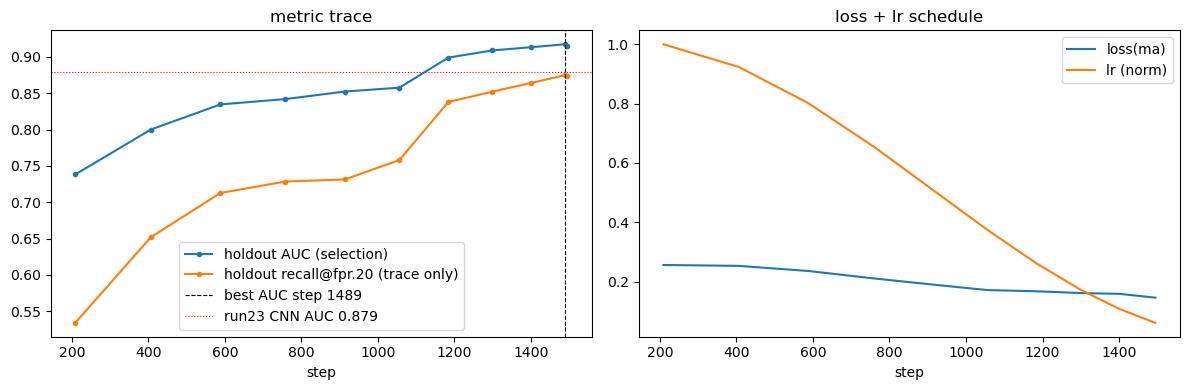

In [32]:
seed.set_deterministic(0)
np.random.seed(0); torch.manual_seed(0)

model = build_capacity_cnn()
print(f"params={n_params(model):,}  blocks={CNN_BLOCKS}  size={TRAIN_IMG_SIZE}  channels_last={CHANNELS_LAST}")
deadline = time.monotonic() + CNN_BUDGET_S
t0 = time.monotonic()
best, history, total_steps, final_eval_s = train_capacity(model, deadline)
cnn_train_s = time.monotonic() - t0
print(f"\ntrained {total_steps} steps in {cnn_train_s:.0f}s  "
      f"({total_steps/(len(X_fit)/BATCH):.1f} epochs)")
print(f"best (by holdout AUC): auc={best['auc']:.3f} recall={best['recall']:.3f} "
      f"fpr={best['fpr']:.3f} at step {best['step']}/{total_steps}   final eval={final_eval_s:.1f}s")

model.load_state_dict(best["state"])
model.eval()
torch.save({"state": best["state"], "arch": "capacity_v1",
            "widths": (32, 64, 128, 256), "blocks": CNN_BLOCKS,
            "img_size": TRAIN_IMG_SIZE, "channels_last": CHANNELS_LAST,
            "mean": MEAN, "std": STD, "thr": best["thr"]},
           str(NBCACHE / "cnn_capacity.pt"))

hist = pd.DataFrame(history)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["step"], hist["auc"], "-o", ms=3, label="holdout AUC (selection)")
ax[0].plot(hist["step"], hist["recall"], "-o", ms=3, label="holdout recall@fpr.20 (trace only)")
ax[0].axvline(best["step"], color="k", ls="--", lw=0.8, label=f"best AUC step {best['step']}")
ax[0].axhline(0.879, color="r", ls=":", lw=0.8, label="run23 CNN AUC 0.879")
ax[0].set_xlabel("step"); ax[0].legend(); ax[0].set_title("metric trace")
ax[1].plot(hist["step"], hist["loss"], label="loss(ma)")
ax[1].plot(hist["step"], hist["lr"] / hist["lr"].max(), label="lr (norm)")
ax[1].set_xlabel("step"); ax[1].legend(); ax[1].set_title("loss + lr schedule")
plt.tight_layout(); plt.show()

## C.6 - RF refit + ensemble + calibration

Same RF recipe as run 23 on the cached 101-dim features. Ensemble alpha chosen by
holdout AUC; threshold calibrated on `calibration` reals at target FPR 0.18 (idea 2:
0.02 headroom for the cal->val gap that pushed run 25 over 0.20).

In [33]:
rf_t0 = time.monotonic()
rf = RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=0,
                            class_weight="balanced", max_features="sqrt")
rf.fit(F_fit, y_fit)
rf_train_s = time.monotonic() - rf_t0
print(f"RF trained in {rf_train_s:.1f}s")

S = TRAIN_IMG_SIZE
p_cnn = {s: cnn_scores(model, X, MEAN, STD, target_size=S)
         for s, X in [("hold", X_hold), ("cal", X_cal), ("val", X_val), ("va", X_va)]}
p_rf  = {s: rf.predict_proba(Ff)[:, 1]
         for s, Ff in [("hold", F_hold), ("cal", F_cal), ("val", F_val), ("va", F_va)]}

print("\nalpha sweep on holdout (CNN weight):")
best_alpha = {"v": 0.5, "auc": -1.0}
for alpha in np.linspace(0.0, 1.0, 11):
    p_h = alpha * p_cnn["hold"] + (1 - alpha) * p_rf["hold"]
    auc = float(roc_auc_score(y_hold, p_h))
    if auc > best_alpha["auc"]:
        best_alpha = {"v": float(alpha), "auc": auc}
    print(f"  alpha={alpha:.1f}  holdout_auc={auc:.4f}")
ALPHA = best_alpha["v"]
print(f"best alpha={ALPHA:.2f}  holdout AUC={best_alpha['auc']:.4f}")

p_ens = {s: ALPHA * p_cnn[s] + (1 - ALPHA) * p_rf[s] for s in p_cnn}
thr_cnn = pick_threshold_for_fpr(p_cnn["cal"][y_cal == 0], target_fpr=TARGET_FPR_CAL)
thr_rf  = pick_threshold_for_fpr(p_rf["cal"][y_cal == 0],  target_fpr=TARGET_FPR_CAL)
thr_ens = pick_threshold_for_fpr(p_ens["cal"][y_cal == 0], target_fpr=TARGET_FPR_CAL)
print(f"thr_cnn={thr_cnn:.4f}  thr_rf={thr_rf:.4f}  thr_ens={thr_ens:.4f}")

RF trained in 11.0s

alpha sweep on holdout (CNN weight):
  alpha=0.0  holdout_auc=0.8852
  alpha=0.1  holdout_auc=0.9086
  alpha=0.2  holdout_auc=0.9226
  alpha=0.3  holdout_auc=0.9298
  alpha=0.4  holdout_auc=0.9328
  alpha=0.5  holdout_auc=0.9332
  alpha=0.6  holdout_auc=0.9317
  alpha=0.7  holdout_auc=0.9292
  alpha=0.8  holdout_auc=0.9258
  alpha=0.9  holdout_auc=0.9218
  alpha=1.0  holdout_auc=0.9173
best alpha=0.50  holdout AUC=0.9332
thr_cnn=0.4342  thr_rf=0.8575  thr_ens=0.6119


## C.7 - Final metrics + run-23 comparison

CNN / RF / ensemble across holdout, cal, val, val_aug at calibrated thresholds.
Validation splits are touched only here. Last cell prints explicit pass/fail vs
run 23.

In [34]:
splits = {"holdout": (y_hold, src_hold), "cal": (y_cal, src_cal),
          "val": (y_val, src_val), "val_aug": (y_va, src_va)}
key = {"holdout": "hold", "cal": "cal", "val": "val", "val_aug": "va"}

rows = []
for model_name, pdict, thr in [("CNN", p_cnn, thr_cnn), ("RF", p_rf, thr_rf), ("ENS", p_ens, thr_ens)]:
    print(f"\n=== {model_name} (thr={thr:.3f}, alpha={ALPHA:.2f}) ===")
    for split, (yy, ss) in splits.items():
        m = metrics_block(yy, pdict[key[split]], ss, threshold=thr, target_fpr=TARGET_FPR_CAL)
        print_metrics(f"{model_name} {split}", m)
        rows.append({"model": model_name, "split": split,
                     **{k: m[k] for k in ("recall_ai", "fpr_real", "roc_auc", "threshold", "n")}})

eval_df = pd.DataFrame(rows).round(3)
eval_df.to_csv(NBCACHE / "eval_capacity.csv", index=False)
print("\n", eval_df.to_string(index=False))


=== CNN (thr=0.434, alpha=0.50) ===
[CNN holdout]  recall_ai=0.821  fpr_real=0.152  prec_ai=0.964  acc=0.826  f1=0.887  auc=0.917  thr=0.434  n=2970
    confusion: tn=420 fp=75 fn=443 tp=2032   per-class AI: SD2.1:0.79  SDXL:0.91  SD3:0.67  DALL-E3:0.93  Midjourney:0.81
[CNN cal]  recall_ai=0.820  fpr_real=0.177  prec_ai=0.958  acc=0.820  f1=0.884  auc=0.907  thr=0.434  n=1924
    confusion: tn=265 fp=57 fn=289 tp=1313   per-class AI: SD2.1:0.74  SDXL:0.90  SD3:0.68  DALL-E3:0.95  Midjourney:0.83
[CNN val]  recall_ai=0.812  fpr_real=0.191  prec_ai=0.955  acc=0.811  f1=0.878  auc=0.882  thr=0.434  n=1124
    confusion: tn=152 fp=36 fn=176 tp=760   per-class AI: SD2.1:0.76  SDXL:0.89  SD3:0.64  DALL-E3:0.94  Midjourney:0.83
[CNN val_aug]  recall_ai=0.724  fpr_real=0.326  prec_ai=0.917  acc=0.715  f1=0.809  auc=0.775  thr=0.434  n=1124
    confusion: tn=126 fp=61 fn=259 tp=678   per-class AI: SD2.1:0.74  SDXL:0.82  SD3:0.54  DALL-E3:0.80  Midjourney:0.72

=== RF (thr=0.858, alpha=0.50) =

In [35]:
# Comparison vs run 23 (PASS baseline), 24 (first capacity CNN), 25 (full budget), 26 (idea 2, the
# current best clean PASS). For idea 3 the bar is run-26 holdout AUC (CNN 0.916 / ENS 0.928).
run23 = {
    ("CNN", "holdout", "roc_auc"): 0.879,
    ("CNN", "val", "recall_ai"): 0.724, ("CNN", "val", "fpr_real"): 0.197, ("CNN", "val", "roc_auc"): 0.850,
    ("ENS", "val", "recall_ai"): 0.811, ("ENS", "val", "fpr_real"): 0.170, ("ENS", "val", "roc_auc"): 0.888,
}
run24 = {
    ("CNN", "holdout", "roc_auc"): 0.915,
    ("CNN", "val", "recall_ai"): 0.833, ("CNN", "val", "fpr_real"): 0.186, ("CNN", "val", "roc_auc"): 0.889,
    ("ENS", "val", "recall_ai"): 0.849, ("ENS", "val", "fpr_real"): 0.186, ("ENS", "val", "roc_auc"): 0.903,
}
run25 = {
    ("CNN", "holdout", "roc_auc"): 0.919,
    ("CNN", "val", "recall_ai"): 0.859, ("CNN", "val", "fpr_real"): 0.218, ("CNN", "val", "roc_auc"): 0.908,
    ("ENS", "val", "recall_ai"): 0.879, ("ENS", "val", "fpr_real"): 0.207, ("ENS", "val", "roc_auc"): 0.914,
}
run26 = {
    ("CNN", "holdout", "roc_auc"): 0.916,
    ("CNN", "val", "recall_ai"): 0.817, ("CNN", "val", "fpr_real"): 0.165, ("CNN", "val", "roc_auc"): 0.888,
    ("ENS", "holdout", "roc_auc"): 0.928,
    ("ENS", "val", "recall_ai"): 0.837, ("ENS", "val", "fpr_real"): 0.191, ("ENS", "val", "roc_auc"): 0.902,
}
baselines = {"run23": run23, "run24": run24, "run25": run25, "run26": run26}
g = {(r["model"], r["split"]): r for r in rows}

def line(model, split, metric, hi_good=True):
    cur = g[(model, split)][metric]
    parts = [f"{model} {split} {metric}: {cur:.3f}"]
    for name, b in baselines.items():
        base = b.get((model, split, metric))
        if base is not None:
            d = cur - base
            arrow = "better" if (d > 0) == hi_good else "worse"
            parts.append(f"vs {name} {base:.3f} ({d:+.3f} {arrow})")
    print("  " + "   ".join(parts))

print("this run vs run 23 / 24 / 25 / 26:")
line("CNN", "holdout", "roc_auc")
line("CNN", "val", "recall_ai"); line("CNN", "val", "fpr_real", hi_good=False); line("CNN", "val", "roc_auc")
line("ENS", "holdout", "roc_auc")
line("ENS", "val", "recall_ai"); line("ENS", "val", "fpr_real", hi_good=False); line("ENS", "val", "roc_auc")

print("\nsuccess criteria:")
cnn_auc = g[("CNN", "holdout")]["roc_auc"]
ens_auc = g[("ENS", "holdout")]["roc_auc"]
cv = g[("CNN", "val")]; ev = g[("ENS", "val")]
print(f"  [{'PASS' if cnn_auc > 0.879 else 'FAIL'}] CNN holdout AUC > 0.879  ({cnn_auc:.3f})")
print(f"  [{'PASS' if ev['roc_auc'] > 0.888 else 'FAIL'}] ENS val AUC > 0.888  ({ev['roc_auc']:.3f})")
print(f"  idea-3 gate: ENS holdout AUC {ens_auc:.3f} vs run26 0.928 "
      f"({ens_auc - 0.928:+.3f}); beat by > 0.003 to justify the extra capacity")
cnn_op = cv["recall_ai"] >= 0.80 and cv["fpr_real"] <= 0.20
ens_op = ev["recall_ai"] >= 0.80 and ev["fpr_real"] <= 0.20
print(f"  [{'PASS' if cnn_op else 'FAIL'}] CNN-only val recall >= 0.80 @ fpr <= 0.20  "
      f"({cv['recall_ai']:.3f} @ {cv['fpr_real']:.3f})")
print(f"  [{'PASS' if ens_op else 'FAIL'}] ENS val recall >= 0.80 @ fpr <= 0.20  "
      f"({ev['recall_ai']:.3f} @ {ev['fpr_real']:.3f})")

this run vs run 23 / 24 / 25 / 26:
  CNN holdout roc_auc: 0.917   vs run23 0.879 (+0.038 better)   vs run24 0.915 (+0.002 better)   vs run25 0.919 (-0.002 worse)   vs run26 0.916 (+0.001 better)
  CNN val recall_ai: 0.812   vs run23 0.724 (+0.088 better)   vs run24 0.833 (-0.021 worse)   vs run25 0.859 (-0.047 worse)   vs run26 0.817 (-0.005 worse)
  CNN val fpr_real: 0.191   vs run23 0.197 (-0.006 better)   vs run24 0.186 (+0.005 worse)   vs run25 0.218 (-0.027 better)   vs run26 0.165 (+0.026 worse)
  CNN val roc_auc: 0.882   vs run23 0.850 (+0.032 better)   vs run24 0.889 (-0.007 worse)   vs run25 0.908 (-0.026 worse)   vs run26 0.888 (-0.006 worse)
  ENS holdout roc_auc: 0.933   vs run26 0.928 (+0.005 better)
  ENS val recall_ai: 0.842   vs run23 0.811 (+0.031 better)   vs run24 0.849 (-0.007 worse)   vs run25 0.879 (-0.037 worse)   vs run26 0.837 (+0.005 better)
  ENS val fpr_real: 0.213   vs run23 0.170 (+0.043 worse)   vs run24 0.186 (+0.027 worse)   vs run25 0.207 (+0.006 worse

## C.7b - Report figures

Regenerates the figures the report embeds (`fig4` training trace, `fig5` confusion
matrices, `fig6` per-source-class recall) plus `fig7` (capacity-vs-compute, the new
notebook's replacement for the old hyperparameter-ablation figure) and `fig8`/`fig9`
worst-case FP/FN diagnostics. All saved to `report/figures/` with the existing names,
so they are drop-in replacements for the archived notebook 02 outputs.

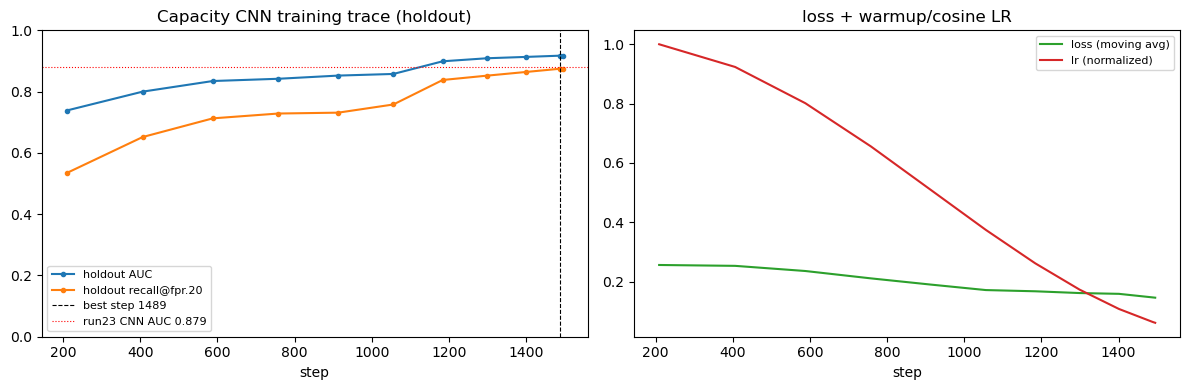

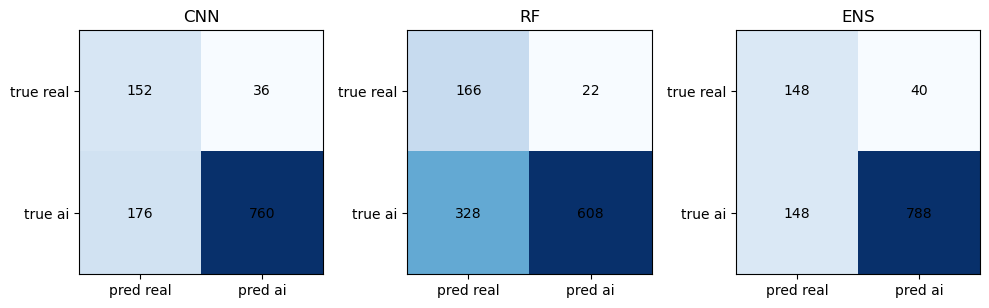

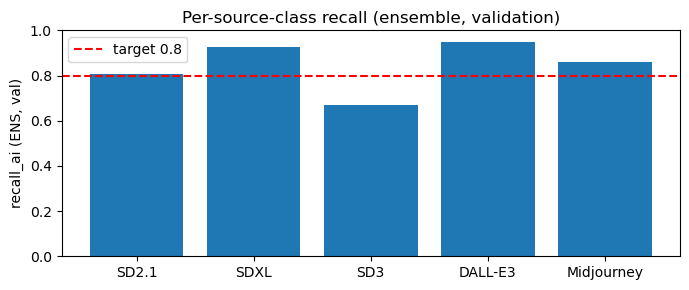

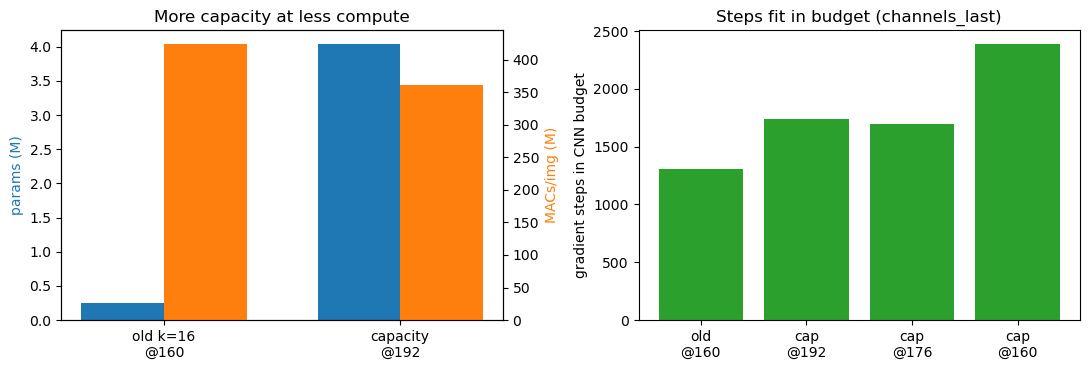

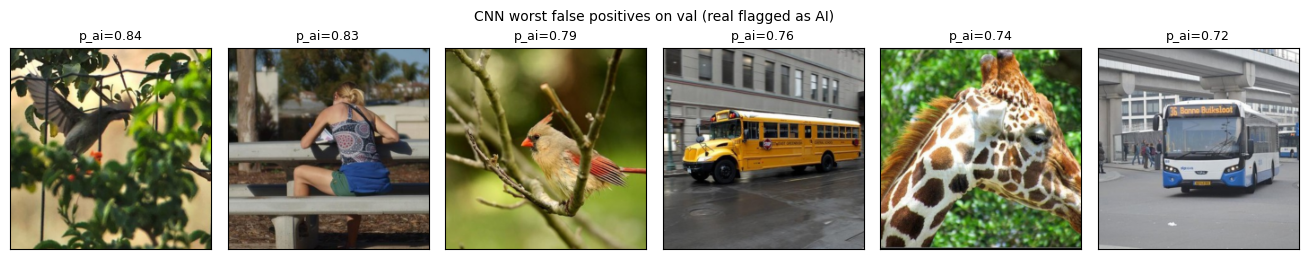

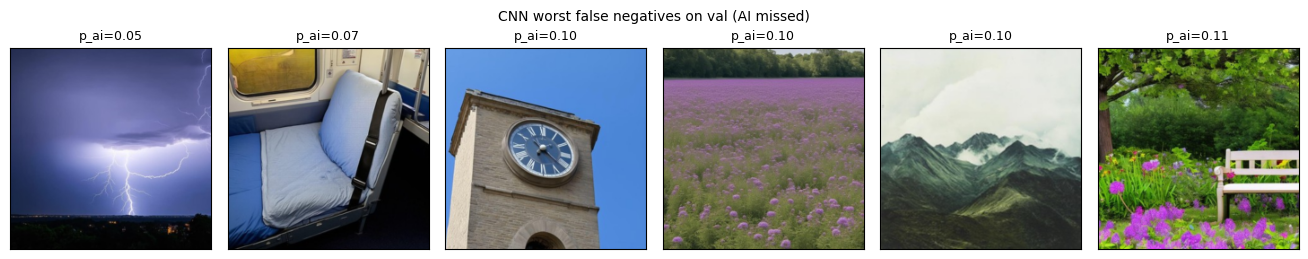

In [36]:
# Report figures (parity with the archived notebook 02). Saved to report/figures/.
REPORT_FIG = ROOT / "report" / "figures"
REPORT_FIG.mkdir(parents=True, exist_ok=True)

# fig4: training trace (AUC/recall + loss/lr vs step)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["step"], hist["auc"], "C0-o", ms=3, label="holdout AUC")
ax[0].plot(hist["step"], hist["recall"], "C1-o", ms=3, label="holdout recall@fpr.20")
ax[0].axvline(best["step"], color="k", ls="--", lw=0.8, label=f"best step {best['step']}")
ax[0].axhline(0.879, color="r", ls=":", lw=0.8, label="run23 CNN AUC 0.879")
ax[0].set_xlabel("step"); ax[0].set_ylim(0, 1); ax[0].legend(fontsize=8)
ax[0].set_title("Capacity CNN training trace (holdout)")
ax[1].plot(hist["step"], hist["loss"], "C2-", label="loss (moving avg)")
ax[1].plot(hist["step"], hist["lr"] / hist["lr"].max(), "C3-", label="lr (normalized)")
ax[1].set_xlabel("step"); ax[1].legend(fontsize=8); ax[1].set_title("loss + warmup/cosine LR")
plt.tight_layout()
plt.savefig(REPORT_FIG / "fig4_training_trace.png", dpi=150, bbox_inches="tight")
plt.show()

# fig5: confusion matrices CNN / RF / ENS on validation
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, (label, p, thr) in zip(axes, [("CNN", p_cnn["val"], thr_cnn),
                                      ("RF",  p_rf["val"],  thr_rf),
                                      ("ENS", p_ens["val"], thr_ens)]):
    yp = (p >= thr).astype(int)
    cm = confusion_matrix(y_val, yp, labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xticks([0, 1], ["pred real", "pred ai"])
    ax.set_yticks([0, 1], ["true real", "true ai"])
    ax.set_title(label)
plt.tight_layout()
plt.savefig(REPORT_FIG / "fig5_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# fig6: per-source-class recall (ENS, validation)
m_ens_val = metrics_block(y_val, p_ens["val"], src_val, threshold=thr_ens, target_fpr=TARGET_FPR_CAL)
pcr = m_ens_val["per_source_class_recall"]
classes = list(range(1, 6))
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar([CLASS_NAMES[c] for c in classes], [pcr[c] for c in classes])
ax.set_ylabel("recall_ai (ENS, val)"); ax.set_ylim(0, 1)
ax.axhline(0.8, color="red", ls="--", label="target 0.8"); ax.legend()
plt.title("Per-source-class recall (ensemble, validation)")
plt.tight_layout()
plt.savefig(REPORT_FIG / "fig6_per_class_recall.png", dpi=150, bbox_inches="tight")
plt.show()

# fig7: capacity-vs-compute (replaces the old hyperparameter ablation figure).
# Panel A: more parameters at fewer MACs. Panel B: more gradient steps fit in budget.
old_m, new_m = build_cnn_bn(k=16), build_capacity_cnn()
old_steps = int(CNN_BUDGET_S / time_steps(build_cnn_bn(k=16), 160, False))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
names = ["old k=16\n@160", "capacity\n@192"]
xs = np.arange(len(names)); w = 0.35
a, a2 = axes[0], axes[0].twinx()
a.bar(xs - w/2, [n_params(old_m)/1e6, n_params(new_m)/1e6], w, color="C0", label="params (M)")
a2.bar(xs + w/2, [count_macs(old_m, 160)/1e6, count_macs(new_m, 192)/1e6], w, color="C1", label="MACs/img (M)")
a.set_xticks(xs, names); a.set_ylabel("params (M)", color="C0"); a2.set_ylabel("MACs/img (M)", color="C1")
a.set_title("More capacity at less compute")
res = [("old\n@160", old_steps), ("cap\n@192", bench[(192, True)][1]),
       ("cap\n@176", bench[(176, True)][1]), ("cap\n@160", bench[(160, True)][1])]
axes[1].bar([r[0] for r in res], [r[1] for r in res], color="C2")
axes[1].set_ylabel("gradient steps in CNN budget")
axes[1].set_title("Steps fit in budget (channels_last)")
plt.tight_layout()
plt.savefig(REPORT_FIG / "fig7_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
del old_m, new_m

# fig8 / fig9: CNN worst false positives / false negatives on validation
def show_top(title, mask, scores, X_u8, order, n=6, save=None):
    pop_idx = np.where(mask)[0]
    if len(pop_idx) == 0:
        print(f"no {title}"); return
    take = np.argsort(-scores[pop_idx] if order == "desc" else scores[pop_idx])[:n]
    chosen = pop_idx[take]
    fig, axes = plt.subplots(1, len(chosen), figsize=(2.2 * len(chosen), 2.6))
    if len(chosen) == 1:
        axes = [axes]
    for ax, gi in zip(axes, chosen):
        ax.imshow(X_u8[gi]); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"p_ai={scores[gi]:.2f}", fontsize=9)
    fig.suptitle(title, fontsize=10); plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()

show_top("CNN worst false positives on val (real flagged as AI)",
         y_val == 0, p_cnn["val"], X_val, "desc", save=REPORT_FIG / "fig8_worst_fps.png")
show_top("CNN worst false negatives on val (AI missed)",
         y_val == 1, p_cnn["val"], X_val, "asc", save=REPORT_FIG / "fig9_worst_fns.png")

## C.7c - Budget proof + CNN-only vs ENS decision

The whole shipped pipeline must fit in 5x reference. CNN training is deadline-bounded to
`BUDGET_S - 45s`; the 45s reserve covers the in-budget post-CNN work that runs during grading -
the idea-2 guaranteed final holdout eval (~8s) + RF refit (~10s) + calibration + save. This cell
asserts that work actually fit the reserve and that the total stays within 5x, then reports the
CNN-only vs ENS head-to-head on validation. Only the SHIPPED model's training counts toward 5x:
CNN-only counts the CNN alone; ENS also counts the RF. If the ensemble no longer adds meaningful
AUC, ship CNN-only (simpler, all budget to the still-improving CNN).

In [37]:
# Budget proof + CNN-only vs ENS decision.
# The whole shipped pipeline must fit in 5x: CNN training (deadline-bounded) + the post-CNN work
# that runs in-budget during grading. That post-CNN work is the guaranteed final holdout eval
# (idea 2) + RF refit + calibration + save; the reserve had to cover it, and here we verify it did.
#   CNN-only ship -> counts cnn_train_s + (cal + save, ~negligible)
#   ENS ship      -> counts cnn_train_s + rf_train_s + (cal + save)
# cnn_train_s already includes the post-deadline final eval (it is measured around train_capacity).
# The C.3 timing benchmark is measurement and is NOT counted (same convention as train.py).
post_cnn_s = final_eval_s + rf_train_s   # in-budget post-deadline work (cal + save are ~1s)
ens_total = cnn_train_s + rf_train_s
print(f"reference       = {REF_S:.1f}s   (5x budget = {BUDGET_S:.0f}s)")
print(f"CNN train       = {cnn_train_s:6.1f}s   reserve = {CNN_BUDGET_RESERVE_S:.0f}s")
print(f"post-CNN work   = {post_cnn_s:6.1f}s   (final eval {final_eval_s:.1f}s + RF {rf_train_s:.1f}s)")
print(f"CNN-only total ~= {cnn_train_s:6.1f}s = {cnn_train_s/REF_S:.2f}x")
print(f"ENS     total   = {ens_total:6.1f}s = {ens_total/REF_S:.2f}x")
assert post_cnn_s <= CNN_BUDGET_RESERVE_S, f"post-CNN work {post_cnn_s:.1f}s exceeded reserve {CNN_BUDGET_RESERVE_S:.0f}s"
assert ens_total <= BUDGET_S, f"ENS pipeline over 5x: {ens_total:.1f}s > {BUDGET_S:.0f}s"

# Head-to-head on validation at calibrated thresholds (rows collected in g)
cnn = g[("CNN", "val")]; ens = g[("ENS", "val")]
auc_gain = ens["roc_auc"] - cnn["roc_auc"]
print("\n=== CNN-only vs ENS (validation) ===")
print(f"CNN-only: recall={cnn['recall_ai']:.3f}  fpr={cnn['fpr_real']:.3f}  AUC={cnn['roc_auc']:.3f}")
print(f"ENS     : recall={ens['recall_ai']:.3f}  fpr={ens['fpr_real']:.3f}  AUC={ens['roc_auc']:.3f}")
print(f"ENS adds {auc_gain:+.3f} val AUC over CNN-only")

def passes(m):
    return m["recall_ai"] >= 0.80 and m["fpr_real"] <= 0.20
cnn_ok, ens_ok = passes(cnn), passes(ens)
print("\n=== Exit criteria (recall >= 0.80 @ fpr <= 0.20, validation) ===")
print(f"CNN-only: {'PASS' if cnn_ok else 'FAIL'}")
print(f"ENS     : {'PASS' if ens_ok else 'FAIL'}")

MEANINGFUL_AUC = 0.005   # ENS must add at least this much val AUC to be worth the RF + budget
print("\nRECOMMENDATION:")
if cnn_ok and auc_gain < MEANINGFUL_AUC:
    print(f"  ship CNN-only - passes, and ENS adds only {auc_gain:+.3f} AUC; drops the RF and is simpler.")
elif ens_ok and auc_gain >= MEANINGFUL_AUC:
    print(f"  keep ENS - adds {auc_gain:+.3f} AUC and stays within 5x ({ens_total/REF_S:.2f}x).")
elif cnn_ok:
    print(f"  ship CNN-only - passes; ENS adds only {auc_gain:+.3f} AUC, not worth the RF.")
else:
    print("  neither candidate passes cleanly at this calibration - inspect thresholds / rerun.")

reference       = 155.6s   (5x budget = 778s)
CNN train       =  741.8s   reserve = 45s
post-CNN work   =   19.3s   (final eval 8.3s + RF 11.0s)
CNN-only total ~=  741.8s = 4.77x
ENS     total   =  752.8s = 4.84x

=== CNN-only vs ENS (validation) ===
CNN-only: recall=0.812  fpr=0.191  AUC=0.882
ENS     : recall=0.842  fpr=0.213  AUC=0.901
ENS adds +0.020 val AUC over CNN-only

=== Exit criteria (recall >= 0.80 @ fpr <= 0.20, validation) ===
CNN-only: PASS
ENS     : FAIL

RECOMMENDATION:
  ship CNN-only - passes; ENS adds only +0.020 AUC, not worth the RF.


## C.8 - Outcome and next steps

This notebook runs idea 3a (logged in `task12_experiment_log.md`): the run-26 pipeline (step-based
eval, AUC selection, guaranteed final eval, target 0.18) with one architecture change -
`CNN_BLOCKS = (2,2,2,3)`, a 3rd block in stage 4. After running, record it as the next run in the
log and check:
- **decision gate (C.7):** does holdout AUC beat run 26 (CNN 0.916 / ENS 0.928) by more than noise
  (~0.003)? It costs ~12% throughput (~1,430 steps vs 1,607), so this is capacity-vs-steps within
  5x. If it does not clear the gate, capacity at the top is tapped out - revert to (2,2,2,2) and
  keep run 26 as the architecture;
- the budget proof (C.7c) still asserts post-CNN work <= 45s reserve and total <= 5x;
- the trace: best-AUC step vs total steps.

Remaining (after the architecture is settled):
- **idea 4 (last):** full CNN train time + final CNN-only vs ENS - set `CNN_BUDGET_RESERVE_S ~15`
  (no RF reserve, CNN ~763s) to measure a true max-budget CNN-only and make the CNN-vs-ENS call on
  the winning architecture (see the log, Finding E).
- a constant-LR tail (SWA) only if we ever want snapshot averaging to pay (cosine-to-0 makes plain
  averaging a no-op or worse - see the log).

Porting to the submission (only when we commit to it, keeps `_lib` clean until then):
1. Add `SEBlock`, `BasicBlock`, `CapacityCNN`, `build_capacity_cnn` to
   `solution/_lib/model.py` as NEW symbols (do not touch `build_cnn_bn`).
2. Add the warmup+cosine, step-based-eval `train_capacity` as a variant (keep `train_cnn`); the
   guaranteed-final-eval + reserve logic ports unchanged. Persist `blocks` in the checkpoint.
3. Branch checkpoint loading on the `arch` key: `eval_saved.py:38`, `predict.py`, `train.py`
   currently assume `build_cnn_bn(k=ckpt["k"])`.
4. Task 1.3: re-run the augmented fine-tune from this backbone - the val_aug fix lives there.